In [ ]:
from opt import *
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.initializers import random_uniform, glorot_uniform
from tensorflow.keras.layers import BatchNormalization, Input, Add, Dense, Activation, ZeroPadding2D, Flatten, Conv2D, AveragePooling2D, MaxPooling2D
from tensorflow.keras.models import Model

from matplotlib.pyplot import imshow

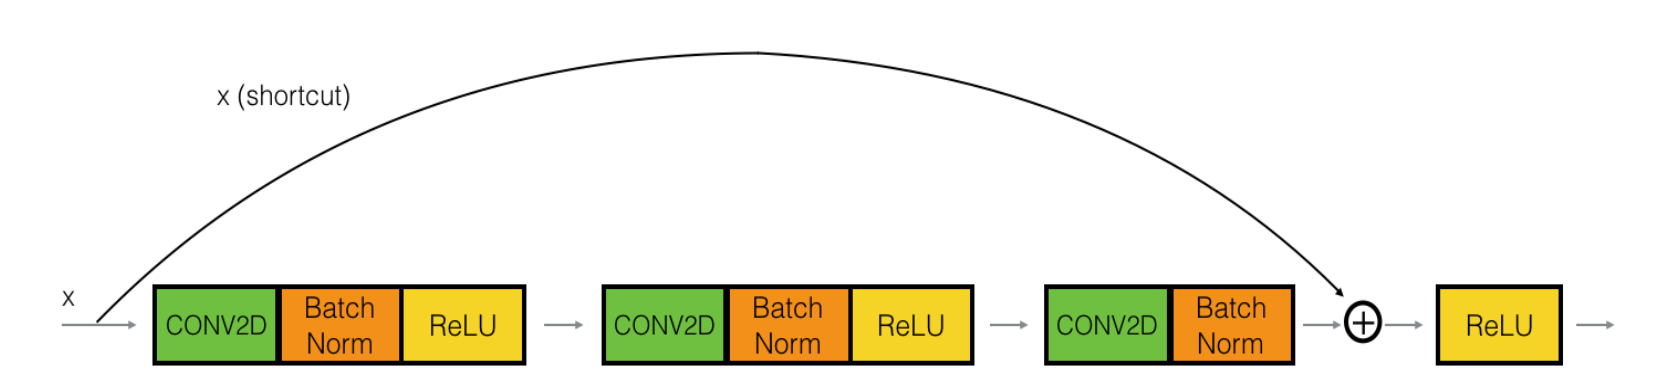

In [4]:
def identity_block(X, f, filters, initializer=random_uniform):

    
    # Lấy số lượng filter (channel) cho từng bước
    F1, F2, F3 = filters
    
    X_shortcut = X
    
    # same để giữ nguyên kích thước W & H, valid để giảm kích thước W & H
    # BatchNormalization(axis = 3): chuẩn hóa channel
    X = Conv2D(filters = F1, kernel_size = 1, strides = (1,1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False) 
    X = Activation('relu')(X)
    
    X = Conv2D(filters = F2, kernel_size = f, strides = (1,1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False)
    X = Activation('relu')(X) 

    X = Conv2D(filters = F3, kernel_size = 1, strides = (1,1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False) 
    
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X) 

    return X

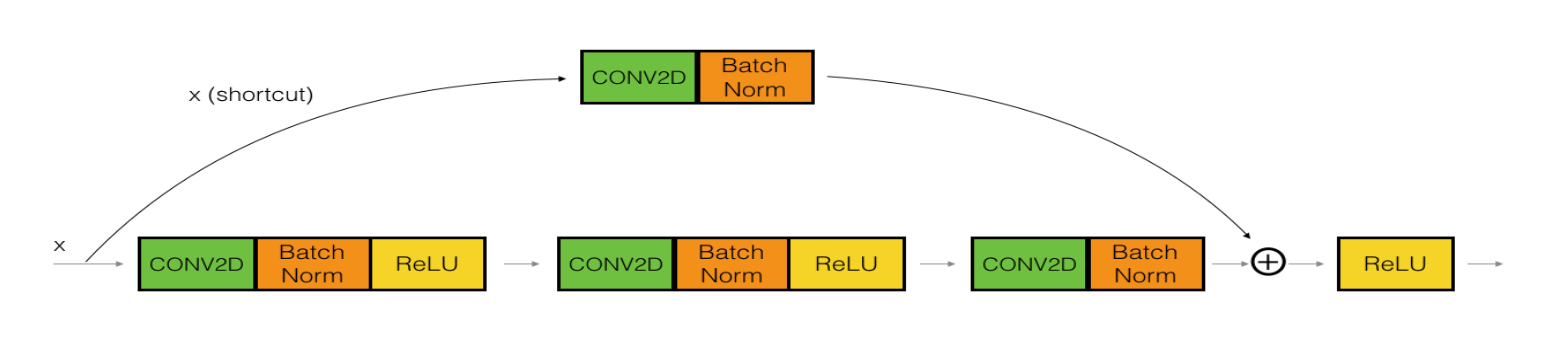

In [5]:
def convolutional_block(X, f, filters, s = 2, initializer=glorot_uniform):

    F1, F2, F3 = filters
    
    X_shortcut = X

    X = Conv2D(filters = F1, kernel_size = 1, strides = (s, s), padding='valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False)
    X = Activation('relu')(X)

    
    X = Conv2D(filters = F2, kernel_size = f, strides = (1, 1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False)
    X = Activation('relu')(X)

    X = Conv2D(filters = F3, kernel_size = 1, strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False)
    
    # X_shortcut đi qua Conv2D với strides = (s, s) để nó nhỏ đi đúng bằng mức Main Path đã làm, và filters = F3 để nó dày bằng Main Path.
    X_shortcut = Conv2D(filters = F3, kernel_size = 1, strides = (s, s), padding = 'valid', kernel_initializer = initializer(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(axis = 3)(X_shortcut, training=False)
    

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    
    return X

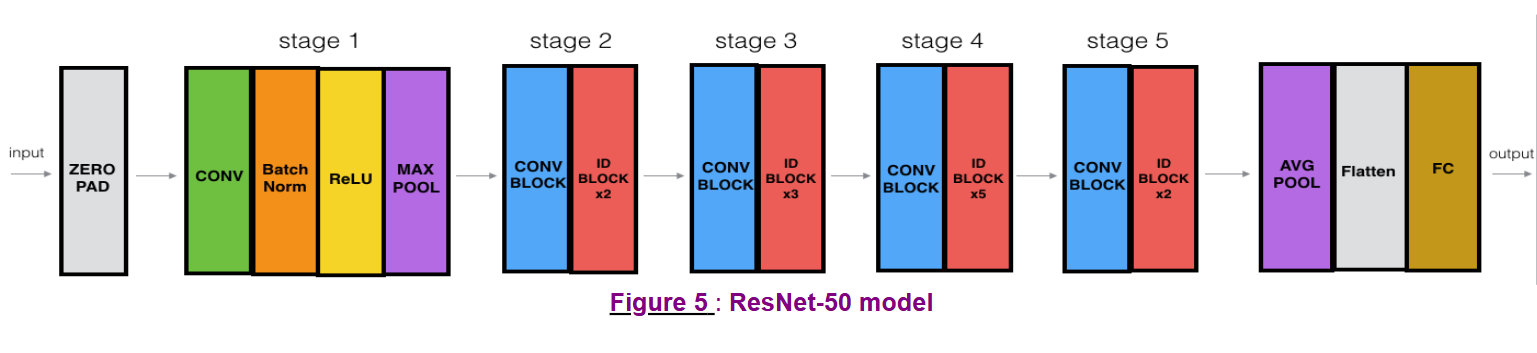

In [ ]:
def ResNet50(input_shape = (64, 64, 3), classes = 6):

    X_input = Input(input_shape)

    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)
    
    # Stage 1
    X = Conv2D(64, (7, 7), strides = (2, 2), kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=False)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f = 3, filters = [64, 64, 256], s = 1)
    X = identity_block(X, 3, [64, 64, 256])
    X = identity_block(X, 3, [64, 64, 256])

    # Stage 3
    # Filters: [128, 128, 512], f = 3, s = 2
    X = convolutional_block(X, f = 3, filters = [128, 128, 512], s = 2)
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])

    # Stage 4
    # Filters: [256, 256, 1024], f = 3, s = 2
    X = convolutional_block(X, f = 3, filters = [256, 256, 1024], s = 2)
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])

    # Stage 5
    # Filters: [512, 512, 2048], f = 3, s = 2
    X = convolutional_block(X, f = 3, filters = [512, 512, 2048], s = 2)
    X = identity_block(X, 3, [512, 512, 2048])
    X = identity_block(X, 3, [512, 512, 2048])

    # AVGPOOL. Sử dụng pool_size=(2,2)
    X = AveragePooling2D(pool_size=(2, 2))(X)
    
    # output layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', kernel_initializer = glorot_uniform(seed=0))(X)
    
    
    # Create model
    model = Model(inputs = X_input, outputs = X)

    return model

In [7]:
model = ResNet50(input_shape = (64, 64, 3), classes = 6)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      9,472 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 15, 15,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 15, 15,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 15, 15,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 15, 15,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 15, 15,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │     16,640 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


In [8]:
np.random.seed(1)
tf.random.set_seed(2)
opt = tf.keras.optimizers.Adam(learning_rate=0.00015)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

# Normalize image vectors
X_train = X_train_orig / 255.
X_test = X_test_orig / 255.

# Convert training and test labels to one hot matrices
Y_train = convert_to_one_hot(Y_train_orig, 6).T
Y_test = convert_to_one_hot(Y_test_orig, 6).T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [10]:
model.fit(X_train, Y_train, epochs = 20, batch_size = 32)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 813ms/step - accuracy: 0.3611 - loss: 1.8122
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 840ms/step - accuracy: 0.6204 - loss: 0.9650
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 760ms/step - accuracy: 0.8352 - loss: 0.4430
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 772ms/step - accuracy: 0.9444 - loss: 0.1635
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 778ms/step - accuracy: 0.9806 - loss: 0.0686
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 766ms/step - accuracy: 0.9833 - loss: 0.0514
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 783ms/step - accuracy: 0.9806 - loss: 0.0578
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 765ms/step - accuracy: 0.9324 - loss: 0.2165
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 761ms/step - accuracy: 0.9046 - loss: 0.2774
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 764ms/step - accuracy: 0.9296 - loss: 0.2115
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 789ms/step - accuracy: 0.9435 - loss: 0.1954
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26

In [11]:
preds = model.evaluate(X_test, Y_test)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.8083 - loss: 1.0704
Loss = 1.070400357246399
Test Accuracy = 0.8083333373069763


Input image shape: (1, 64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Class prediction vector [p(0), p(1), p(2), p(3), p(4), p(5)] =  [[2.86337745e-08 8.70329302e-07 9.99998212e-01 1.73209802e-08
  1.08558126e-07 7.36233744e-07]]
Class: 2


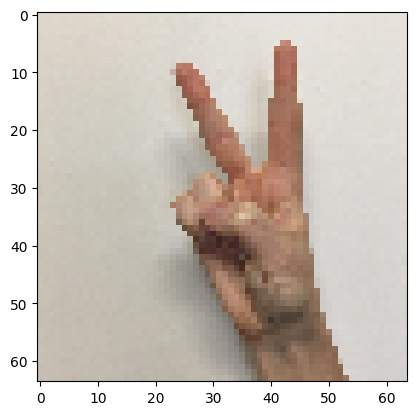

In [ ]:
img_path = 'images/my_image.jpg'
img = image.load_img(img_path, target_size=(64, 64))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

x = x/255.0
x2 = x 

print('Input image shape:', x.shape)
imshow(img)
prediction = model.predict(x2)
print("Class prediction vector [p(0), p(1), p(2), p(3), p(4), p(5)] = ", prediction)
print("Class:", np.argmax(prediction))